In [1]:
from collections import OrderedDict
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from datasets.utils.logging import disable_progress_bar
from torch.utils.data import DataLoader

import flwr
from flwr.client import Client, ClientApp, NumPyClient
from flwr.common import Metrics, Context
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg
from flwr.simulation import run_simulation
from flwr_datasets import FederatedDataset

DEVICE = torch.device("cpu")  # Try "cuda" to train on GPU
print(f"Training on {DEVICE}")
print(f"Flower {flwr.__version__} / PyTorch {torch.__version__}")
disable_progress_bar()

Training on cpu
Flower 1.30.0 / PyTorch 2.12.0+cpu


CIFAR-10 enables us to train image classifiers that distinguish between images from ten distinct classes:

- **‘Airplane’**
- **‘Automobile’**
- **‘Bird’**
- **‘Cat’**
- **‘Deer’**
- **‘Dog’**
- **‘Frog’**
- **‘Horse’**
- **‘Ship’**
- **‘Truck’**

In [3]:
NUM_CLIENTS = 10
BATCH_SIZE = 32


def load_datasets(partition_id: int):
    fds = FederatedDataset(dataset="cifar10", partitioners={"train": NUM_CLIENTS})
    partition = fds.load_partition(partition_id)
    # Divide data on each node: 80% train, 20% test
    partition_train_test = partition.train_test_split(test_size=0.2, seed=42)
    pytorch_transforms = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    def apply_transforms(batch):
        # Instead of passing transforms to CIFAR10(..., transform=transform)
        # we will use this function to dataset.with_transform(apply_transforms)
        # The transforms object is exactly the same
        batch["img"] = [pytorch_transforms(img) for img in batch["img"]]
        return batch

    # Create train/val for each partition and wrap it into DataLoader
    partition_train_test = partition_train_test.with_transform(apply_transforms)
    trainloader = DataLoader(
        partition_train_test["train"], batch_size=BATCH_SIZE, shuffle=True
    )
    valloader = DataLoader(partition_train_test["test"], batch_size=BATCH_SIZE)
    testset = fds.load_split("test").with_transform(apply_transforms)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE)
    return trainloader, valloader, testloader

Let’s take a look at the first batch of images and labels in the first training set (i.e., trainloader from partition_id=0) before we move on:



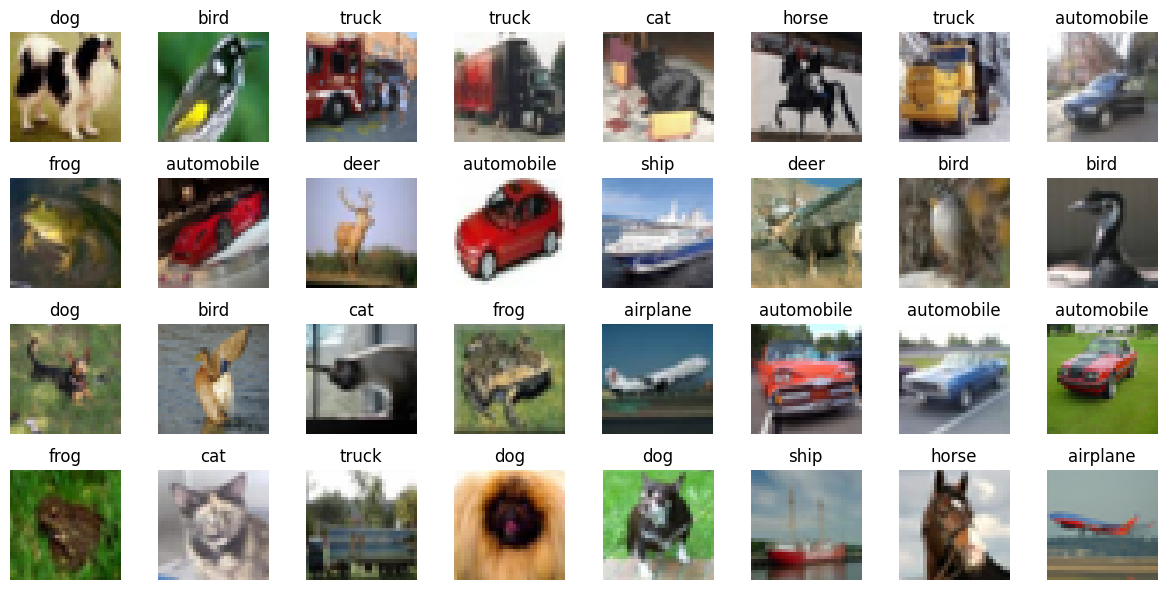

In [4]:
trainloader, _, _ = load_datasets(partition_id=0)
batch = next(iter(trainloader))
images, labels = batch["img"], batch["label"]

# Reshape and convert images to a NumPy array
# matplotlib requires images with the shape (height, width, 3)
images = images.permute(0, 2, 3, 1).numpy()

# Denormalize
images = images / 2 + 0.5

# Create a figure and a grid of subplots
fig, axs = plt.subplots(4, 8, figsize=(12, 6))

# Loop over the images and plot them
for i, ax in enumerate(axs.flat):
    ax.imshow(images[i])
    ax.set_title(trainloader.dataset.features["label"].int2str([labels[i]])[0])
    ax.axis("off")

# Show the plot
fig.tight_layout()
plt.show()

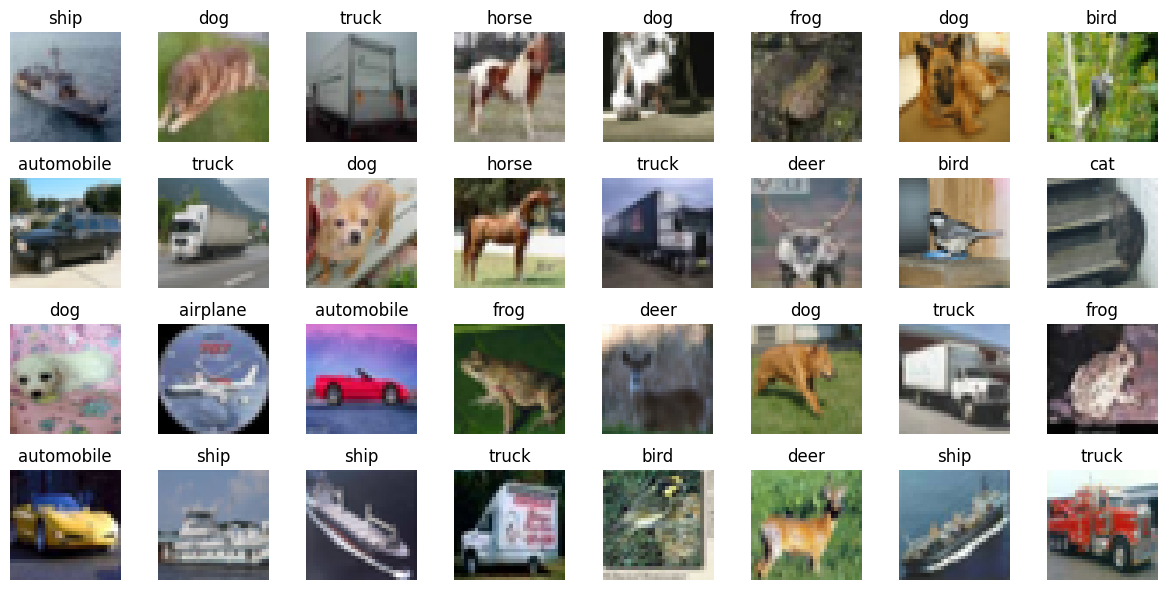

In [4]:
_ , _, trainloader = load_datasets(partition_id=0)
batch = next(iter(trainloader))
images, labels = batch["img"], batch["label"]

# Reshape and convert images to a NumPy array
# matplotlib requires images with the shape (height, width, 3)
images = images.permute(0, 2, 3, 1).numpy()

# Denormalize
images = images / 2 + 0.5

# Create a figure and a grid of subplots
fig, axs = plt.subplots(4, 8, figsize=(12, 6))

# Loop over the images and plot them
for i, ax in enumerate(axs.flat):
    ax.imshow(images[i])
    ax.set_title(trainloader.dataset.features["label"].int2str([labels[i]])[0])
    ax.axis("off")

# Show the plot
fig.tight_layout()
plt.show()

<a id='1'></a>
 # <p style="background-color:skyblue; font-family:newtimeroman; font-size:150%; text-align:center">Step 1: Centralized Training with PyTorch
</p>

Next, we’re going to use PyTorch to define a simple convolutional neural network.

In [5]:
class Net(nn.Module):
    def __init__(self) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

Let’s continue with the usual training and test functions:



In [7]:
def train(net, trainloader, epochs: int, verbose=False, optimizer=None):
    """Train the network on the training set."""
    criterion = torch.nn.CrossEntropyLoss()
    net.train()
    assert optimizer is not None
    for epoch in range(epochs):
        correct, total, epoch_loss = 0, 0, 0.0
        for batch in trainloader:
            images, labels = batch["img"].to(DEVICE), batch["label"].to(DEVICE)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            # Metrics
            epoch_loss += loss
            total += labels.size(0)
            correct += (torch.max(outputs.data, 1)[1] == labels).sum().item()
        epoch_loss /= len(trainloader.dataset)
        epoch_acc = correct / total
        if verbose:
            print(f"Epoch {epoch+1}: train loss {epoch_loss}, accuracy {epoch_acc}")


def test(net, testloader):
    """Evaluate the network on the entire test set."""
    criterion = torch.nn.CrossEntropyLoss()
    correct, total, loss = 0, 0, 0.0
    net.eval()
    with torch.no_grad():
        for batch in testloader:
            images, labels = batch["img"].to(DEVICE), batch["label"].to(DEVICE)
            outputs = net(images)
            loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    loss /= len(testloader.dataset)
    accuracy = correct / total
    return loss, accuracy

# Train the Model

We now have all the basic building blocks we need:

- A **dataset**
- A **model**
- A **training function**
- A **test function**

Let’s put them together to train the model on the dataset of one of our organizations (**`partition_id=0`**). This simulates the reality of most machine learning projects today, where:

> Each organization has its **own data** and trains models only on this **internal data**.


In [8]:
import torch
import torch.nn as nn


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=8, dropout=0.1):
        super().__init__()

        assert dim % num_heads == 0

        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads

        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)

        self.out_proj = nn.Linear(dim, dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

        self.scale = self.head_dim ** -0.5

    def forward(self, x):
        B, N, D = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = torch.softmax(attn, dim=-1)
        attn = self.attn_dropout(attn)

        x = attn @ v

        x = x.transpose(1, 2).reshape(B, N, D)

        x = self.out_proj(x)
        x = self.proj_dropout(x)

        return x


class MLP(nn.Module):
    def __init__(self, dim, mlp_dim, dropout=0.1):
        super().__init__()

        self.fc1 = nn.Linear(dim, mlp_dim)
        self.gelu = nn.GELU()
        self.fc2 = nn.Linear(mlp_dim, dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.dropout(x)

        return x


class TransformerBlock(nn.Module):
    def __init__(
        self,
        dim,
        num_heads,
        mlp_dim,
        dropout=0.1
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(
            dim=dim,
            num_heads=num_heads,
            dropout=dropout
        )

        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(
            dim=dim,
            mlp_dim=mlp_dim,
            dropout=dropout
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ViTNet(nn.Module):
    def __init__(
        self,
        image_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        dim=256,
        depth=6,
        num_heads=8,
        mlp_dim=512,
        dropout=0.1,
    ):
        super().__init__()
        assert image_size % patch_size == 0
        self.patch_size = patch_size
        num_patches = (image_size // patch_size) ** 2
        patch_dim = in_channels * patch_size * patch_size
        self.patch_embedding = nn.Linear(
            patch_dim,
            dim
        )
        self.cls_token = nn.Parameter(
            torch.randn(1, 1, dim)
        )
        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_patches + 1, dim)
        )
        self.embedding_dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(
                dim=dim,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                dropout=dropout
            )
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(
            dim,
            num_classes
        )
    def patchify(self, x):
        B, C, H, W = x.shape
        P = self.patch_size
        x = x.unfold(2, P, P).unfold(3, P, P)
        x = x.permute(0, 2, 3, 1, 4, 5)
        x = x.reshape(
            B,
            -1,
            C * P * P
        )
        return x
    def forward(self, x):
        B = x.shape[0]
        x = self.patchify(x)
        x = self.patch_embedding(x)
        cls_tokens = self.cls_token.expand(
            B,
            -1,
            -1
        )
        x = torch.cat(
            [cls_tokens, x],
            dim=1
        )
        x = x + self.pos_embedding
        x = self.embedding_dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        cls_output = x[:, 0]
        logits = self.head(cls_output)
        return logits

In [11]:
trainloader, valloader, testloader = load_datasets(partition_id=0)
net = ViTNet(
    image_size=32,
    patch_size=4,
    num_classes=10,
    dim=256,
    depth=6,
    num_heads=8,
    mlp_dim=512
).to(DEVICE)

optimizer = torch.optim.AdamW(
    net.parameters(),
    lr=3e-4,
    weight_decay=0.05
)
for epoch in range(100):
    train(net, trainloader, 1,optimizer=optimizer)
    loss, accuracy = test(net, valloader)
    print(f"Epoch {epoch+1}: validation loss {loss}, accuracy {accuracy}")

loss, accuracy = test(net, testloader)
print(f"Final test set performance:\n\tloss {loss}\n\taccuracy {accuracy}")

Epoch 1: validation loss 0.06397281873226165, accuracy 0.298
Epoch 2: validation loss 0.05859495747089386, accuracy 0.345
Epoch 3: validation loss 0.05756418740749359, accuracy 0.346
Epoch 4: validation loss 0.059484503746032716, accuracy 0.339
Epoch 5: validation loss 0.052990009188652036, accuracy 0.41
Epoch 6: validation loss 0.0530314314365387, accuracy 0.403
Epoch 7: validation loss 0.05101652348041535, accuracy 0.432
Epoch 8: validation loss 0.0501580206155777, accuracy 0.451
Epoch 9: validation loss 0.050144609928131106, accuracy 0.456
Epoch 10: validation loss 0.05141664695739746, accuracy 0.448
Epoch 11: validation loss 0.05069758498668671, accuracy 0.455
Epoch 12: validation loss 0.05123436689376831, accuracy 0.449
Epoch 13: validation loss 0.055544357180595395, accuracy 0.451
Epoch 14: validation loss 0.05474857115745545, accuracy 0.454
Epoch 15: validation loss 0.05513653743267059, accuracy 0.45
Epoch 16: validation loss 0.055558348894119265, accuracy 0.453
Epoch 17: valida

KeyboardInterrupt: 

In [12]:

loss, accuracy = test(net, testloader)
print(f"Final test set performance:\n\tloss {loss}\n\taccuracy {accuracy}")

Final test set performance:
	loss 0.09759974575042725
	accuracy 0.4499


### Training the Simple CNN

Training the simple CNN on our **CIFAR-10 split** for **5 epochs** should result in a test set accuracy of about **41%**. While this accuracy is not particularly impressive, it’s not the focus of this tutorial.

The purpose of this step is to:

- Demonstrate a **simple centralized training pipeline**.
- Set the stage for the next step: **federated learning**! 🚀


<a id='1'></a>
 # <p style="background-color:skyblue; font-family:newtimeroman; font-size:150%; text-align:center">Step 2: Federated Learning with Flower</p>

Next, we simulate a scenario where:

- **Multiple datasets** are distributed across **multiple organizations**.
- The model is trained **collaboratively** across these organizations using **federated learning**.

---

## Update Model Parameters in Federated Learning

In **federated learning**, the process works as follows:

1. The **server** sends the **global model parameters** to the client.
2. The **client**:
   - Updates the local model with the **parameters received** from the server.
   - Trains the model on its **local data**, which changes the model parameters locally.
   - Sends the updated/changed **model parameters** back to the server (or, alternatively, just the gradients).

---

## Helper Functions for Parameter Updates

We need two helper functions for the model:

1. **`set_parameters`**: Updates the local model with the parameters received from the server.
2. **`get_parameters`**: Retrieves the updated model parameters from the local model.

In [8]:
def set_parameters(net, parameters: List[np.ndarray]):
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
    net.load_state_dict(state_dict, strict=True)


def get_parameters(net) -> List[np.ndarray]:
    return [val.cpu().numpy() for _, val in net.state_dict().items()]

# Define the Flower `ClientApp`

Now we move on to the exciting part! Federated learning systems consist of:

- A **ServerApp**: Handles the server-side logic.
- A **ClientApp**: Manages the client-side logic.

In **Flower**, we create a `ServerApp` and a `ClientApp` to run the server-side and client-side code, respectively.

---

## Step 1: Creating a `ClientApp`

The first step in creating a `ClientApp` is to implement a subclass of either:

- `flwr.client.Client`, or
- `flwr.client.NumPyClient`.

For simplicity, we use **`NumPyClient`** in this tutorial, as it requires less boilerplate code and is easier to implement.

---

## Step 2: Implementing `NumPyClient`

To implement `NumPyClient`, we need to define a subclass that implements the following three methods:

1. **`get_parameters`**:
   - Returns the current local model parameters.

2. **`fit`**:
   - Receives model parameters from the server.
   - Trains the model on the local data.
   - Returns the updated model parameters to the server.

3. **`evaluate`**:
   - Receives model parameters from the server.
   - Evaluates the model on the local data.
   - Returns the evaluation result to the server.

---

## Step 3: Using PyTorch for Training and Evaluation

The clients will use the previously defined **PyTorch components** for model training and evaluation.

Here is an example implementation of a simple Flower client that ties everything together:

In [9]:
class FlowerClient(NumPyClient):
    def __init__(self, net, trainloader, valloader):
        self.net = net
        self.trainloader = trainloader
        self.valloader = valloader

    def get_parameters(self, config):
        return get_parameters(self.net)

    def fit(self, parameters, config):
        set_parameters(self.net, parameters)
        train(self.net, self.trainloader, epochs=1)
        return get_parameters(self.net), len(self.trainloader), {}

    def evaluate(self, parameters, config):
        set_parameters(self.net, parameters)
        loss, accuracy = test(self.net, self.valloader)
        return float(loss), len(self.valloader), {"accuracy": float(accuracy)}

# Summary: Flower ClientApp

- **`FlowerClient`**:
  - Defines local training (`fit`) and evaluation (`evaluate`) logic.
  - Each client in the federated learning system is represented by an instance of `FlowerClient`.
  - Example: 3 clients = 3 instances of `FlowerClient` (each on a separate machine).

- **Simulation with 10 Clients**:
  - This notebook simulates **10 clients** on a **single machine**, sharing CPU, GPU, and memory.
  - Running all clients simultaneously can exhaust memory, even if only a subset participates in a training round.

- **Optimized Memory Usage**:
  - Flower creates `FlowerClient` instances only when necessary (e.g., for training or evaluation).
  - Instances are discarded after use to save memory.

- **`client_fn` Function**:
  - Dynamically creates `FlowerClient` instances as needed.
  - Uses **`partition-id`** to load specific data partitions for each client.

- **`ClientApp`**:
  - Acts as the entry point for a Flower client.
  - Executes code like `FlowerClient.fit` using the `client_fn`.

This setup efficiently handles federated learning with multiple clients, even on resource-constrained machines.


In [ ]:
def client_fn(context: Context) -> Client:
    """Create a Flower client representing a single organization."""

    # Load model
    net = ViTNet(
    image_size=32,
    patch_size=4,
    num_classes=10,
    dim=256,
    depth=6,
    num_heads=8,
    mlp_dim=512
).to(DEVICE)
    # Load data (CIFAR-10)
    # Note: each client gets a different trainloader/valloader, so each client
    # will train and evaluate on their own unique data partition
    # Read the node_config to fetch data partition associated to this node
    partition_id = context.node_config["partition-id"]
    trainloader, valloader, _ = load_datasets(partition_id=partition_id)

    # Create a single Flower client representing a single organization
    # FlowerClient is a subclass of NumPyClient, so we need to call .to_client()
    # to convert it to a subclass of `flwr.client.Client`
    return FlowerClient(net, trainloader, valloader).to_client()


# Create the ClientApp
client = ClientApp(client_fn=client_fn)

# Define the Flower `ServerApp`

On the **server side**, we configure a **strategy** that encapsulates the federated learning algorithm, such as **Federated Averaging (FedAvg)**. 

## Federated Learning Strategies in Flower
- Flower provides several **built-in strategies**.
- Custom strategy implementations can also be created to fine-tune nearly every aspect of the federated learning process.

---

## Example: Using the Built-In FedAvg Strategy

In this example, we use the built-in **FedAvg** implementation and customize it with a few basic parameters.

In [11]:
# Create FedAvg strategy
strategy = FedAvg(
    fraction_fit=1.0,  # Sample 100% of available clients for training
    fraction_evaluate=0.5,  # Sample 50% of available clients for evaluation
    min_fit_clients=10,  # Never sample less than 10 clients for training
    min_evaluate_clients=5,  # Never sample less than 5 clients for evaluation
    min_available_clients=10,  # Wait until all 10 clients are available
)

In [12]:
def server_fn(context: Context) -> ServerAppComponents:
    """Construct components that set the ServerApp behaviour.

    You can use the settings in `context.run_config` to parameterize the
    construction of all elements (e.g the strategy or the number of rounds)
    wrapped in the returned ServerAppComponents object.
    """

    # Configure the server for 5 rounds of training
    config = ServerConfig(num_rounds=5)

    return ServerAppComponents(strategy=strategy, config=config)


# Create the ServerApp
server = ServerApp(server_fn=server_fn)

# Run the Training

In federated learning simulations, it's important to control the resources allocated to each client. This ensures efficient resource utilization, especially when multiple clients are running on a single machine.

---

## Resource Configuration

To control resource usage, we use the `backend_config` dictionary, which includes the **`client_resources`** key. This key specifies the amount of **CPU** and **GPU** resources each client can access.

### Example Configuration

In [13]:
# Specify the resources each of your clients need
# By default, each client will be allocated 1x CPU and 0x GPUs
backend_config = {"client_resources": {"num_cpus": 1, "num_gpus": 0.0}}

# When running on GPU, assign an entire GPU for each client
if DEVICE.type == "cuda":
    backend_config = {"client_resources": {"num_cpus": 1, "num_gpus": 1.0}}
    # Refer to our Flower framework documentation for more details about Flower simulations
    # and how to set up the `backend_config`

# Final Step: Running the Simulation

The last step is to execute the simulation using the **`run_simulation`** function. This function orchestrates the federated learning simulation by bringing together the **ServerApp**, **ClientApp**, and other configuration details.

---

## Key Arguments for `run_simulation`

1. **`server_app` and `client_app`**:
   - The previously created **ServerApp** and **ClientApp** objects.
   - These handle the server-side and client-side logic, respectively.

2. **`num_supernodes`**:
   - The number of **SuperNodes** to simulate.
   - In Flower simulation, this equals the **number of clients** in the system.

3. **`backend_config`**:
   - Defines the resource allocation for this simulation (e.g., CPU, GPU resources per client).


In [ ]:
# Run simulation
run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=NUM_CLIENTS,
    backend_config=backend_config,
)


            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
ERROR :     Exit Code: 701
`ray` backend selected for simulation, but `ray` is not installed.

Extra dependencies required for simulation are missing.

To use simulation with the Ray backend, install `flwr` with the `simulation` extra:

    `pip install "flwr[simulation]"`.


For more information, visit: <https://flower.ai/docs/framework/1.30/en/ref-exit-codes/701.html>


SystemExit: 1

e:\PYTHON\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


: 

# Handling Custom Metrics in Flower

You may have noticed that metrics like **`accuracy`** are missing in the aggregated results. Flower can automatically aggregate **losses** returned by clients, but it does not handle **custom metrics** (e.g., accuracy) automatically. 

---

## Why is Accuracy Missing?

- The **metrics dictionary** (e.g., `{"accuracy": float(accuracy)}`) can contain diverse data types or key/value pairs that are not metrics.
- Since Flower cannot determine how to handle these metrics automatically, we must define **metric aggregation functions** to specify the aggregation logic.

---

## Metric Aggregation Functions

We can pass custom aggregation functions to the **strategy** to handle metrics. These functions are:

1. **`fit_metrics_aggregation_fn`**:
   - Used to aggregate metrics returned from the **`fit`** method on clients.

2. **`evaluate_metrics_aggregation_fn`**:
   - Used to aggregate metrics returned from the **`evaluate`** method on clients.


In [ ]:
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    # Multiply accuracy of each client by number of examples used
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]

    # Aggregate and return custom metric (weighted average)
    return {"accuracy": sum(accuracies) / sum(examples)}

In [ ]:
def server_fn(context: Context) -> ServerAppComponents:
    """Construct components that set the ServerApp behaviour.

    You can use settings in `context.run_config` to parameterize the
    construction of all elements (e.g the strategy or the number of rounds)
    wrapped in the returned ServerAppComponents object.
    """

    # Create FedAvg strategy
    strategy = FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=0.5,
        min_fit_clients=10,
        min_evaluate_clients=5,
        min_available_clients=10,
        evaluate_metrics_aggregation_fn=weighted_average,  # <-- pass the metric aggregation function
    )

    # Configure the server for 5 rounds of training
    config = ServerConfig(num_rounds=5)

    return ServerAppComponents(strategy=strategy, config=config)


# Create a new server instance with the updated FedAvg strategy
server = ServerApp(server_fn=server_fn)

# Run simulation
run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=NUM_CLIENTS,
    backend_config=backend_config,
)

We now have a full system that performs federated training and federated evaluation. It uses the weighted_average function to aggregate custom evaluation metrics and calculates a single accuracy metric across all clients on the server side.
n.